In [1]:
#load the data
import pandas as pd 

#Load your CSV
df = pd.read_csv("sales_data.csv")

#check data atleast 5 columns to get insights
print(df.head())

#underrstand the data types of each column+ features+ attributes and also check for null values + missing values + number of rows and columns in the data frame
print(df.info())

#To check statistics of the data frame ex: mean, median, mode, standard deviation, min, max, etc. for numerical columns and IQR.
print(df.describe())
 
 #To check columns
 
print(df.columns)

   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-02-03       Bob  North       5053.97             18   
1        1093  2023-04-21       Bob   West       4384.02             17   
2        1015  2023-09-21     David  South       4631.23             30   
3        1072  2023-08-24       Bob  South       2167.94             39   
4        1061  2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  
0           Cash        Online            North-Bob  
1           Cash        Re

In [2]:
#Data Cleaning + Feature Engineering

print(df.isnull().sum()) 

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64


In [3]:
#For practice we will remove ome values from the data frame and then we will handle them
#Let's say we want to remove some values from the 'Sales' column
import numpy as np 
df.loc[0, "Sales_amount"] = np.nan
df.loc[1, "Region"] = np.nan

#Now check again if we have any null datapoints or not
print(df.isnull().sum())


Product_ID                 0
Sale_Date                  0
Sales_Rep                  0
Region                     1
Sales_Amount               0
Quantity_Sold              0
Product_Category           0
Unit_Cost                  0
Unit_Price                 0
Customer_Type              0
Discount                   0
Payment_Method             0
Sales_Channel              0
Region_and_Sales_Rep       0
Sales_amount            1000
dtype: int64


In [4]:
#NOW handle missing values:

df["Sales_Amount"] = df["Sales_Amount"].fillna(df["Sales_Amount"].mean())
#for Region column we can fill the missing value with the unknown:
df["Region"] = df["Region"].fillna("Unknown")
print(df.isnull().sum())


Product_ID                 0
Sale_Date                  0
Sales_Rep                  0
Region                     0
Sales_Amount               0
Quantity_Sold              0
Product_Category           0
Unit_Cost                  0
Unit_Price                 0
Customer_Type              0
Discount                   0
Payment_Method             0
Sales_Channel              0
Region_and_Sales_Rep       0
Sales_amount            1000
dtype: int64


In [5]:
#insights + business understanding + graphs

#Total Sales in business
total_sales=df["Sales_Amount"].sum()
print("Total sale is:", total_sales)

#total sales region wise
region_sales=df.groupby("Region")["Sales_Amount"].sum()
print("The sales by region is:", region_sales)

#Total sale by Top Sales Re--which employee earned more
top_sales_rep=df.groupby("Sales_Rep")["Sales_Amount"].sum().sort_values(ascending=True)
print("The sales by top sales rep is:", top_sales_rep)


Total sale is: 5019265.2299999995
The sales by region is: Region
East       1259792.93
North      1369612.51
South      1154250.86
Unknown       4384.02
West       1231224.91
Name: Sales_Amount, dtype: float64
The sales by top sales rep is: Sales_Rep
Charlie     860811.48
Alice       965541.77
Eve         970183.99
Bob        1080990.63
David      1141737.36
Name: Sales_Amount, dtype: float64


In [6]:
#Profit Analysis 

df["Profit"] = (df["Unit_Price"] - df["Unit_Cost"]) * df["Quantity_Sold"]
print(df[["Unit_Price", "Unit_Cost", "Quantity_Sold", "Profit"]].head())

   Unit_Price  Unit_Cost  Quantity_Sold   Profit
0      267.22     152.75             18  2060.46
1     4209.44    3816.39             17  6681.85
2      371.40     261.56             30  3295.20
3     4467.75    4330.03             39  5371.08
4      692.71     637.37             13   719.42


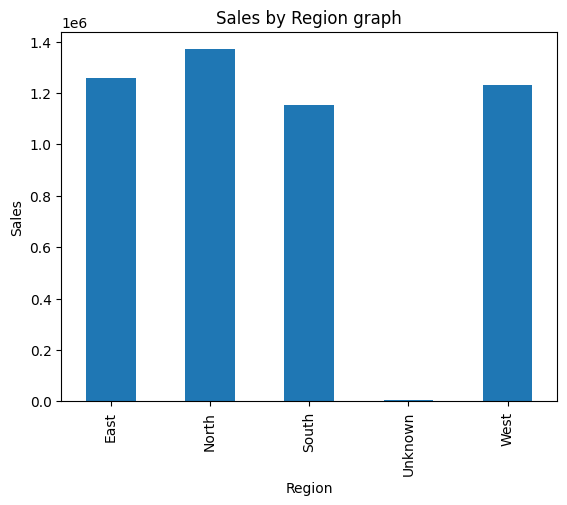

In [7]:
#Visualization (Graphs)
#1. Region vs Sales (BAR CHART)
import matplotlib.pyplot as plt

region_sales = df.groupby("Region")["Sales_Amount"].sum()
region_sales.plot(kind="bar")

plt.title("Sales by Region graph")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()
#comparing each regions sales
#which region is performing best
#why bar chart? to compare categories

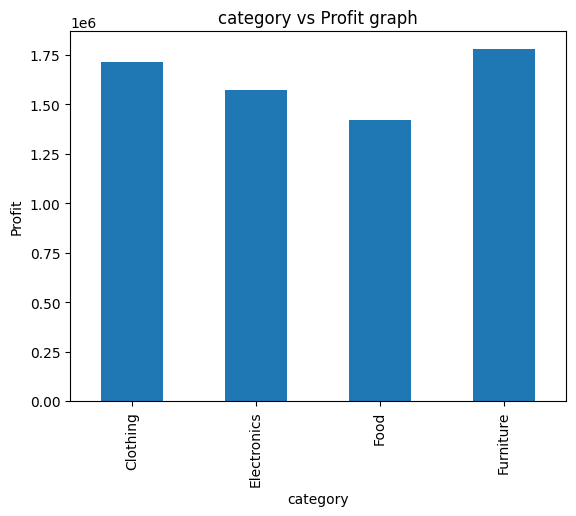

In [8]:

import matplotlib.pyplot as plt
category_profit=df.groupby("Product_Category")["Profit"].sum()
category_profit.plot(kind="bar")

plt.title("category vs Profit graph")
plt.xlabel("category")
plt.ylabel("Profit")

plt.show()

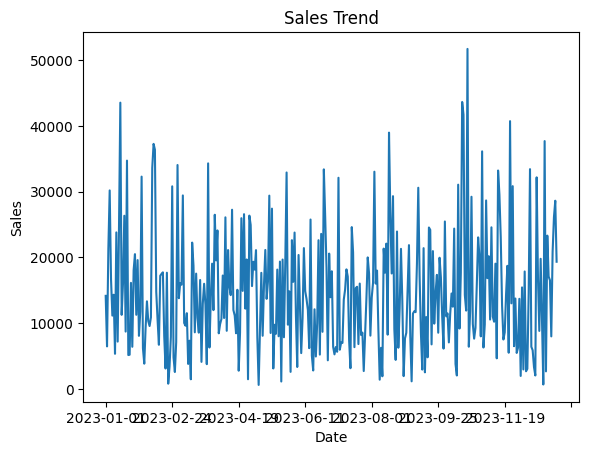

In [9]:
#Sales Trend (LINE CHART)
sales_trend = df.groupby("Sale_Date")["Sales_Amount"].sum()

sales_trend.plot(kind="line")

plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

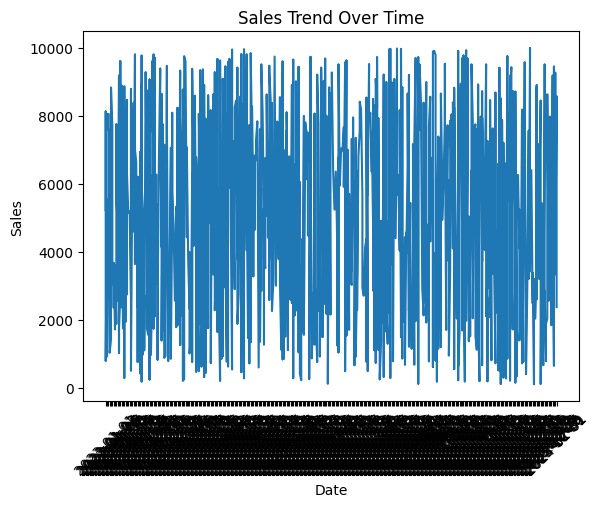

In [10]:
#Second way --fine but messy

df_sorted = df.sort_values("Sale_Date")

plt.plot(df_sorted["Sale_Date"], df_sorted["Sales_Amount"])

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.show()